# 06 -- Cost-Aware Training: Teaching Models to Trade, Not Just Classify

**Phase 6e of the DeepLOB project**

## 1. Motivation

In Phase 6, we discovered a stark disconnect: **the best classifier is the worst trader.**
CNN+Attention achieved the highest classification accuracy (78.98% average across horizons),
but when we backtested all models with realistic transaction costs, every single one lost money.

The core problem: standard cross-entropy loss treats all misclassifications equally, but in
trading, predicting "up" when the price drops costs money, while predicting "stationary" when
the price rises merely misses an opportunity at zero cost.

**Can we redesign the training objective to produce models that are profitable, not just accurate?**

In this notebook, we test 4 cost-aware loss functions across 60 experiments (12 configs × 5 horizons).

## 2. Setup & Data Loading

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import torch

# Project imports
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.backtest import (
    apply_holding_period,
    extract_mid_prices_and_spreads,
    predictions_to_positions,
    run_backtest,
)

# Plot style
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

print(f'Project root: {PROJECT_ROOT}')

Project root: /Users/tt/Individual Projects/deeplob-project


In [2]:
# Load test features and extract market data
test_x = torch.load(PROJECT_ROOT / 'data/processed/test_x.pt', weights_only=True).numpy()
test_y = torch.load(PROJECT_ROOT / 'data/processed/test_y.pt', weights_only=True).numpy()

mid_prices, spreads = extract_mid_prices_and_spreads(test_x)

print(f'Test samples:  {len(test_y):,}')
print(f'Mid-prices:    {len(mid_prices):,} (mean={mid_prices.mean():.4f})')
print(f'Spreads:       mean={spreads.mean():.6f}, median={np.median(spreads):.6f}')

Test samples:  139,488
Mid-prices:    139,488 (mean=0.2352)
Spreads:       mean=0.000360, median=0.000300


In [3]:
# Load baseline predictions from Phase 5-6 for comparison
HORIZON = 10
HORIZON_IDX = {10: 0, 20: 1, 30: 2, 50: 3, 100: 4}

def load_model_predictions(horizon=10):
    """Load predictions for all models at a given horizon."""
    models = {}
    
    # Deep learning models
    dl_models = {
        'DeepLOB': f'experiments/k{horizon}/history.pt',
        'DL-Attention': f'experiments/extension/k{horizon}/history.pt',
        'CNN-Only': f'experiments/ablation/cnn_only/k{horizon}/history.pt',
        'CNN+Attention': f'experiments/ablation/cnn_attention/k{horizon}/history.pt',
    }
    for name, path in dl_models.items():
        h = torch.load(PROJECT_ROOT / path, weights_only=False)
        preds = h['test_predictions'].numpy()
        labels = h['test_labels'].numpy()
        models[name] = {'predictions': preds, 'labels': labels, 'accuracy': (preds == labels).mean()}
    
    # Baseline models
    baseline_models = {
        'XGBoost': f'experiments/baselines/xgboost_k{horizon}.pt',
        'LogReg': f'experiments/baselines/logistic_regression_k{horizon}.pt',
    }
    for name, path in baseline_models.items():
        b = torch.load(PROJECT_ROOT / path, weights_only=False)
        preds = np.array(b['predictions'], dtype=np.int64)
        labels = np.array(b['labels'], dtype=np.int64)
        models[name] = {'predictions': preds, 'labels': labels, 'accuracy': (preds == labels).mean()}
    
    return models

baseline_models = load_model_predictions(HORIZON)

print(f'Phase 5-6 baseline predictions (k={HORIZON}):')
print(f'{"Model":<16} {"Accuracy":>10} {"Samples":>10}')
print('-' * 38)
for name, m in baseline_models.items():
    print(f'{name:<16} {m["accuracy"]:>10.2%} {len(m["predictions"]):>10,}')

Phase 5-6 baseline predictions (k=10):
Model              Accuracy    Samples
--------------------------------------
DeepLOB              81.88%    139,488
DL-Attention         82.44%    139,488
CNN-Only             83.53%    139,488
CNN+Attention        83.84%    139,488
XGBoost              80.16%    139,488
LogReg               72.20%    139,488


In [4]:
# Helper: run backtest and return flat metrics dict for easy access
def quick_backtest(predictions, mid_prices, spreads):
    """Run backtest and return flat dict with key metrics."""
    positions = predictions_to_positions(predictions)
    bt = run_backtest(positions, mid_prices, spreads)
    m = bt['metrics']
    return {
        'net_pnl': m['total_pnl_net'],
        'num_trades': m['num_trades'],
        'sharpe': m['sharpe_ratio'],
        'max_drawdown': m['max_drawdown'],
        'win_rate': m['win_rate'],
        'total_costs': m['total_costs'],
        'frac_flat': m['frac_flat'],
    }

# Run baseline backtests for comparison reference
print('Phase 6 baseline backtests (naive, no post-hoc strategies):')
print(f'{"Model":<16} {"Net PnL":>10} {"Trades":>8} {"Sharpe":>8}')
print('-' * 44)

baseline_results = {}
for name, m in baseline_models.items():
    result = quick_backtest(m['predictions'], mid_prices, spreads)
    baseline_results[name] = result
    print(f'{name:<16} {result["net_pnl"]:>+10.4f} {result["num_trades"]:>8,} {result["sharpe"]:>8.4f}')

print()
print('Reminder: Best post-hoc strategy = LR-Stack h=200 at +0.6880 PnL')

Phase 6 baseline backtests (naive, no post-hoc strategies):
Model               Net PnL   Trades   Sharpe
--------------------------------------------
DeepLOB             -8.0231   37,116  -0.0362
DL-Attention        -8.1976   38,179  -0.0347
CNN-Only            -8.1009   37,127  -0.0390
CNN+Attention       -8.5899   37,470  -0.0420
XGBoost             -5.8258   28,518  -0.0280
LogReg              -0.9028    5,752  -0.0048

Reminder: Best post-hoc strategy = LR-Stack h=200 at +0.6880 PnL


## 3. Weighted Cross-Entropy

**Idea:** Standard cross-entropy treats all misclassifications equally. But from a trading
perspective, predicting a *trade* (Up/Down) when the true label is *Stationary* is far more
costly than the reverse — it triggers an unnecessary position change and incurs transaction costs.

By up-weighting the Stationary class in the loss function, we encourage the model to be more
conservative — only predicting directional moves when it's confident.

**The math:**

Standard CE: $\mathcal{L} = -\sum_c y_c \log(p_c)$

Weighted CE: $\mathcal{L} = -\sum_c w_c \cdot y_c \log(p_c)$ where $w = [1.0, w_{stat}, 1.0]$

With $w_{stat} > 1$, the model pays a **higher price** for incorrectly predicting Up/Down
when the truth is Stationary. This pushes the model toward predicting Stationary more often,
effectively "raising the bar" for directional predictions.

**Limitations:** Applies the same weight to ALL stationary samples, regardless of how close
to the decision boundary they are. A sample that's "barely stationary" gets the same treatment
as one that's "clearly stationary."

**Sweep:** $w_{stat} \in \{2.0, 3.0, 5.0\}$ — increasing the cost of false trades by 2x, 3x, 5x.

  w=2.0: acc=0.8265, naive PnL=-7.7606, h200 PnL=-0.3588, trades(naive)=35,951
  w=3.0: acc=0.8211, naive PnL=-7.2484, h200 PnL=-0.1769, trades(naive)=34,509
  w=5.0: acc=0.8180, naive PnL=-7.8757, h200 PnL=-1.1631, trades(naive)=36,906

Model              Accuracy  Naive PnL   Trades  h=200 PnL
--------------------------------------------------------
DeepLOB (CE)         81.88%    -8.0231   37,116          —
WCE w=2.0            82.65%    -7.7606   35,951    -0.3588
WCE w=3.0            82.11%    -7.2484   34,509    -0.1769
WCE w=5.0            81.80%    -7.8757   36,906    -1.1631


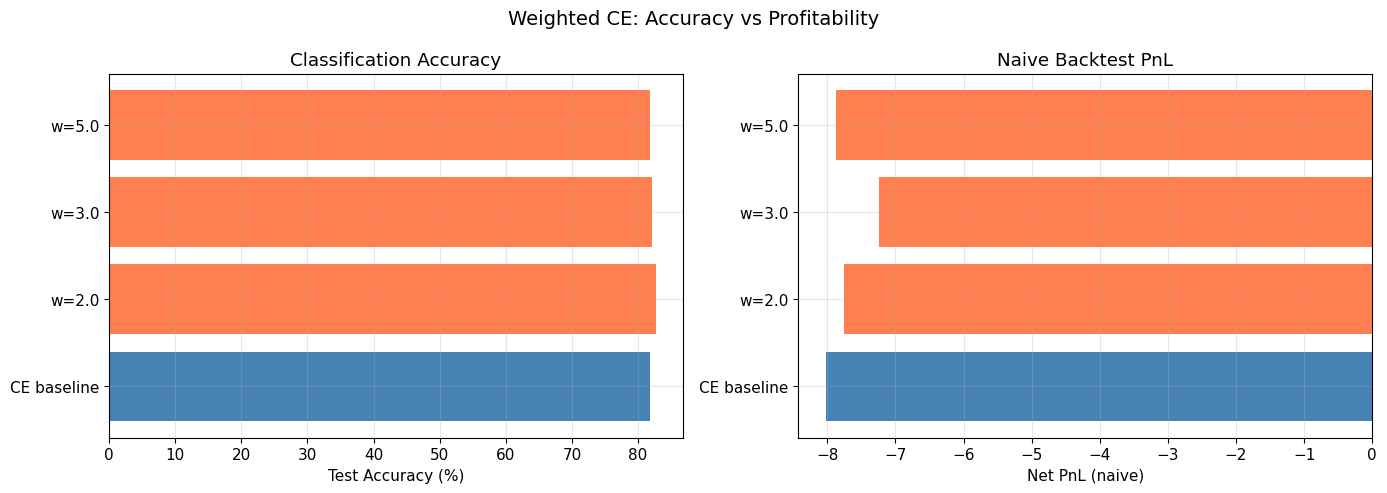

In [5]:
# --- Load Weighted CE experiment results ---
wce_experiments = {
    'w=2.0': PROJECT_ROOT / 'experiments/cost_aware/weighted_ce/w2.0/k10/history.pt',
    'w=3.0': PROJECT_ROOT / 'experiments/cost_aware/weighted_ce/w3.0/k10/history.pt',
    'w=5.0': PROJECT_ROOT / 'experiments/cost_aware/weighted_ce/w5.0/k10/history.pt',
}

wce_results = {}
for name, path in wce_experiments.items():
    if path.exists():
        h = torch.load(path, weights_only=False, map_location='cpu')
        preds = h['test_predictions'].numpy()
        labels = h['test_labels'].numpy()
        acc = (preds == labels).mean()
        
        # Naive backtest
        bt = quick_backtest(preds, mid_prices, spreads)
        
        # With holding period h=200 — optimal value from Phase 6 grid search (notebook 05)
        preds_h200 = apply_holding_period(preds, min_hold=200)
        bt_h200 = quick_backtest(preds_h200, mid_prices, spreads)
        
        wce_results[name] = {
            'accuracy': acc,
            'f1': h.get('test_f1_weighted', 0),
            'naive_pnl': bt['net_pnl'],
            'naive_trades': bt['num_trades'],
            'naive_sharpe': bt['sharpe'],
            'h200_pnl': bt_h200['net_pnl'],
            'h200_trades': bt_h200['num_trades'],
            'h200_sharpe': bt_h200['sharpe'],
            'best_epoch': h.get('best_epoch', 0),
        }
        print(f"  {name}: acc={acc:.4f}, naive PnL={bt['net_pnl']:+.4f}, "
              f"h200 PnL={bt_h200['net_pnl']:+.4f}, trades(naive)={bt['num_trades']:,}")
    else:
        print(f"  {name}: NOT FOUND — run experiments on Amarel first")

if not wce_results:
    print("\nNo weighted CE experiments found.")
    print("Run: bash scripts/slurm/train_cost_aware_all.sh")
else:
    # --- Comparison table ---
    print(f"\n{'Model':<16} {'Accuracy':>10} {'Naive PnL':>10} {'Trades':>8} {'h=200 PnL':>10}")
    print('-' * 56)
    bl = baseline_results['DeepLOB']
    print(f"{'DeepLOB (CE)':<16} {baseline_models['DeepLOB']['accuracy']:>10.2%} "
          f"{bl['net_pnl']:>+10.4f} {bl['num_trades']:>8,} {'—':>10}")
    for name, r in wce_results.items():
        print(f"{'WCE ' + name:<16} {r['accuracy']:>10.2%} "
              f"{r['naive_pnl']:>+10.4f} {r['naive_trades']:>8,} {r['h200_pnl']:>+10.4f}")
    
    # --- Plot accuracy vs PnL tradeoff ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    names = ['CE baseline'] + list(wce_results.keys())
    accs = [baseline_models['DeepLOB']['accuracy']] + [r['accuracy'] for r in wce_results.values()]
    colors = ['steelblue'] + ['coral'] * len(wce_results)
    axes[0].barh(names, [a * 100 for a in accs], color=colors)
    axes[0].set_xlabel('Test Accuracy (%)')
    axes[0].set_title('Classification Accuracy')
    
    pnls = [bl['net_pnl']] + [r['naive_pnl'] for r in wce_results.values()]
    axes[1].barh(names, pnls, color=colors)
    axes[1].axvline(x=0, color='k', linewidth=0.5)
    axes[1].set_xlabel('Net PnL (naive)')
    axes[1].set_title('Naive Backtest PnL')
    
    plt.suptitle('Weighted CE: Accuracy vs Profitability', fontsize=14)
    plt.tight_layout()
    plt.show()

## 4. Turnover-Penalized Loss

**Idea:** Add an explicit penalty for prediction changes between consecutive timesteps.
The total loss becomes:

$$\mathcal{L} = \mathcal{L}_{CE} + \lambda \cdot \mathcal{L}_{turnover}$$

**How the turnover penalty works:**

1. Convert logits to "soft positions" via softmax:
   $$\text{pos}_t = P(\text{Up})_t - P(\text{Down})_t \in [-1, 1]$$
   
   This maps the 3-class probabilities to a continuous signal:
   - pos ~ +1: strong buy (high P(Up))
   - pos ~ 0: flat (high P(Stationary) or uncertain)
   - pos ~ -1: strong sell (high P(Down))

2. Compute turnover between consecutive timesteps:
   $$\mathcal{L}_{turnover} = \frac{1}{B-1}\sum_{t=1}^{B-1} |\text{pos}_t - \text{pos}_{t-1}|$$

**Why this works:** Adjacent LOB snapshots (t and t+1) differ by only one new event — their
information content is ~99% overlapping. So the model's predictions SHOULD be smooth over time.
But standard CE treats each sample independently with no incentive for smoothness. The turnover
penalty adds that incentive: **"if you want to change your prediction, that change better be
worth the penalty."**

**Important:** Requires sequential (non-shuffled) data loading! Consecutive samples in
each batch must be consecutive in time.

**Sweep:** $\lambda \in \{0.01, 0.1, 0.5\}$

  lam=0.01: acc=0.7310, stability=0.9349, naive PnL=-3.1351, trades=9,078
  lam=0.1: acc=0.7222, stability=0.8830, naive PnL=-4.1021, trades=16,322


  lam=0.5: acc=0.7181, stability=0.9283, naive PnL=-2.9982, trades=9,998

Model              Accuracy  Stability  Naive PnL   Trades  h=200 PnL
------------------------------------------------------------------
DeepLOB (CE)         81.88%     0.7339    -8.0231   37,116          —
Turn lam=0.01        73.10%     0.9349    -3.1351    9,078    -0.0006
Turn lam=0.1         72.22%     0.8830    -4.1021   16,322    -0.4701
Turn lam=0.5         71.81%     0.9283    -2.9982    9,998    -0.3267


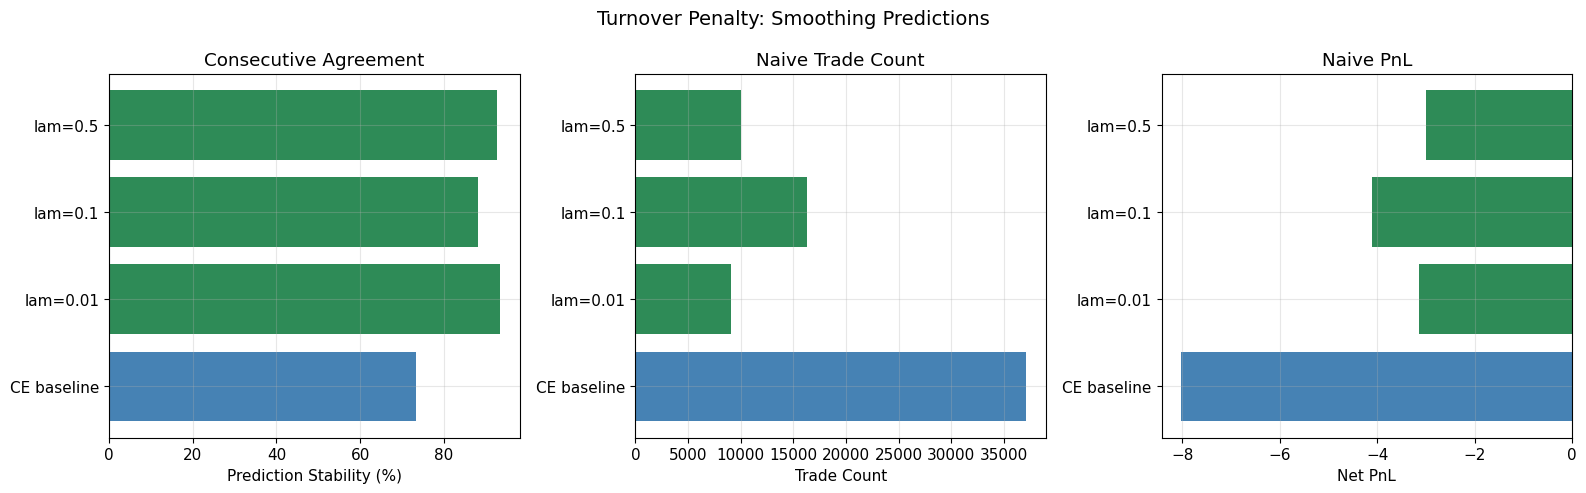

In [6]:
# --- Load Turnover-Penalized experiment results ---
turn_experiments = {
    'lam=0.01': PROJECT_ROOT / 'experiments/cost_aware/turnover/lam0.01/k10/history.pt',
    'lam=0.1':  PROJECT_ROOT / 'experiments/cost_aware/turnover/lam0.1/k10/history.pt',
    'lam=0.5':  PROJECT_ROOT / 'experiments/cost_aware/turnover/lam0.5/k10/history.pt',
}

turn_results = {}
for name, path in turn_experiments.items():
    if path.exists():
        h = torch.load(path, weights_only=False, map_location='cpu')
        preds = h['test_predictions'].numpy()
        labels = h['test_labels'].numpy()
        acc = (preds == labels).mean()
        
        # Prediction stability: fraction of consecutive predictions that are identical
        stability = (preds[1:] == preds[:-1]).mean()
        
        # Naive backtest
        bt = quick_backtest(preds, mid_prices, spreads)
        
        # With holding period
        preds_h200 = apply_holding_period(preds, min_hold=200)
        bt_h200 = quick_backtest(preds_h200, mid_prices, spreads)
        
        turn_results[name] = {
            'accuracy': acc,
            'stability': stability,
            'naive_pnl': bt['net_pnl'],
            'naive_trades': bt['num_trades'],
            'naive_sharpe': bt['sharpe'],
            'h200_pnl': bt_h200['net_pnl'],
            'h200_trades': bt_h200['num_trades'],
        }
        print(f"  {name}: acc={acc:.4f}, stability={stability:.4f}, "
              f"naive PnL={bt['net_pnl']:+.4f}, trades={bt['num_trades']:,}")
    else:
        print(f"  {name}: NOT FOUND — run experiments on Amarel first")

if not turn_results:
    print("\nNo turnover experiments found.")
    print("Run: bash scripts/slurm/train_cost_aware_all.sh")
else:
    # --- Baseline stability for comparison ---
    bl_preds = baseline_models['DeepLOB']['predictions']
    bl_stability = (bl_preds[1:] == bl_preds[:-1]).mean()
    
    # --- Table ---
    print(f"\n{'Model':<16} {'Accuracy':>10} {'Stability':>10} {'Naive PnL':>10} "
          f"{'Trades':>8} {'h=200 PnL':>10}")
    print('-' * 66)
    bl = baseline_results['DeepLOB']
    print(f"{'DeepLOB (CE)':<16} {baseline_models['DeepLOB']['accuracy']:>10.2%} "
          f"{bl_stability:>10.4f} {bl['net_pnl']:>+10.4f} {bl['num_trades']:>8,} {'—':>10}")
    for name, r in turn_results.items():
        print(f"{'Turn ' + name:<16} {r['accuracy']:>10.2%} "
              f"{r['stability']:>10.4f} {r['naive_pnl']:>+10.4f} "
              f"{r['naive_trades']:>8,} {r['h200_pnl']:>+10.4f}")
    
    # --- Plot: Stability vs Trade Count vs PnL ---
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    names = ['CE baseline'] + list(turn_results.keys())
    stabs = [bl_stability] + [r['stability'] for r in turn_results.values()]
    trades = [bl['num_trades']] + [r['naive_trades'] for r in turn_results.values()]
    pnls = [bl['net_pnl']] + [r['naive_pnl'] for r in turn_results.values()]
    colors = ['steelblue'] + ['seagreen'] * len(turn_results)
    
    axes[0].barh(names, [s * 100 for s in stabs], color=colors)
    axes[0].set_xlabel('Prediction Stability (%)')
    axes[0].set_title('Consecutive Agreement')
    
    axes[1].barh(names, trades, color=colors)
    axes[1].set_xlabel('Trade Count')
    axes[1].set_title('Naive Trade Count')
    
    axes[2].barh(names, pnls, color=colors)
    axes[2].axvline(x=0, color='k', linewidth=0.5)
    axes[2].set_xlabel('Net PnL')
    axes[2].set_title('Naive PnL')
    
    plt.suptitle('Turnover Penalty: Smoothing Predictions', fontsize=14)
    plt.tight_layout()
    plt.show()

## 5. Differentiable Sharpe Ratio Loss

**Idea:** Why optimize a classification proxy at all? The Sharpe ratio directly measures
risk-adjusted return — exactly what we care about. By constructing a differentiable
approximation of the Sharpe ratio, we can backpropagate through the trading P&L itself.

**The pipeline (all differentiable):**

$$\text{logits} \xrightarrow{\text{softmax}} \text{probs} \xrightarrow{P(\text{Up})-P(\text{Down})} \text{positions} \xrightarrow{\times \Delta\text{price}} \text{returns} \xrightarrow{-\text{costs}} \text{net returns} \xrightarrow{\text{mean}/\text{std}} \text{Sharpe}$$

**Step by step:**
1. **Positions** from softmax: $\text{pos}_t = P(\text{Up})_t - P(\text{Down})_t \in [-1, 1]$
2. **Returns**: $R_t = \text{pos}_t \times (\text{price}_{t+1} - \text{price}_t)$
3. **Transaction costs**: $TC_t = \gamma \times \text{spread}_t \times |\text{pos}_t - \text{pos}_{t-1}|$
4. **Net returns**: $NR_t = R_t - TC_t$
5. **Loss**: $\mathcal{L} = -\frac{\text{mean}(NR)}{\text{std}(NR) + \epsilon} + \lambda \cdot \text{turnover}$

**The half-cost trick** (Wood et al., 2025): Training with $\gamma=1.0$ (full transaction cost)
causes an "inertia trap" — the model learns to never trade. Training with $\gamma=0$ ignores
costs entirely. $\gamma=0.5$ is the sweet spot: cost-aware but not paralyzed. This improved
net Sharpe by ~50% in published experiments.

**Key requirement:** Warm-start from a pre-trained DeepLOB checkpoint, otherwise the model
starts with random features and can't compute meaningful returns.

**Sweep:** $\lambda_{turnover} \in \{0.01, 0.1, 0.5\}$ with $\gamma_{cost} = 0.5$

  lt=0.01: acc=0.4051, naive PnL=-5.7044, naive Sharpe=-0.0196, flat=44.6%
  lt=0.1: acc=0.4098, naive PnL=-3.0328, naive Sharpe=-0.0086, flat=48.3%
  lt=0.5: acc=0.4134, naive PnL=-4.8862, naive Sharpe=-0.0446, flat=48.1%

Model              Accuracy  Naive PnL   Sharpe   Trades   % Flat  h=200 PnL
------------------------------------------------------------------------
DeepLOB (CE)         81.88%    -8.0231  -0.0362   37,116    78.0%          —
Sharpe lt=0.01       40.51%    -5.7044  -0.0196   27,544    44.6%    -0.6530
Sharpe lt=0.1        40.98%    -3.0328  -0.0086   16,442    48.3%    -0.5701
Sharpe lt=0.5        41.34%    -4.8862  -0.0446   28,135    48.1%    +0.6214


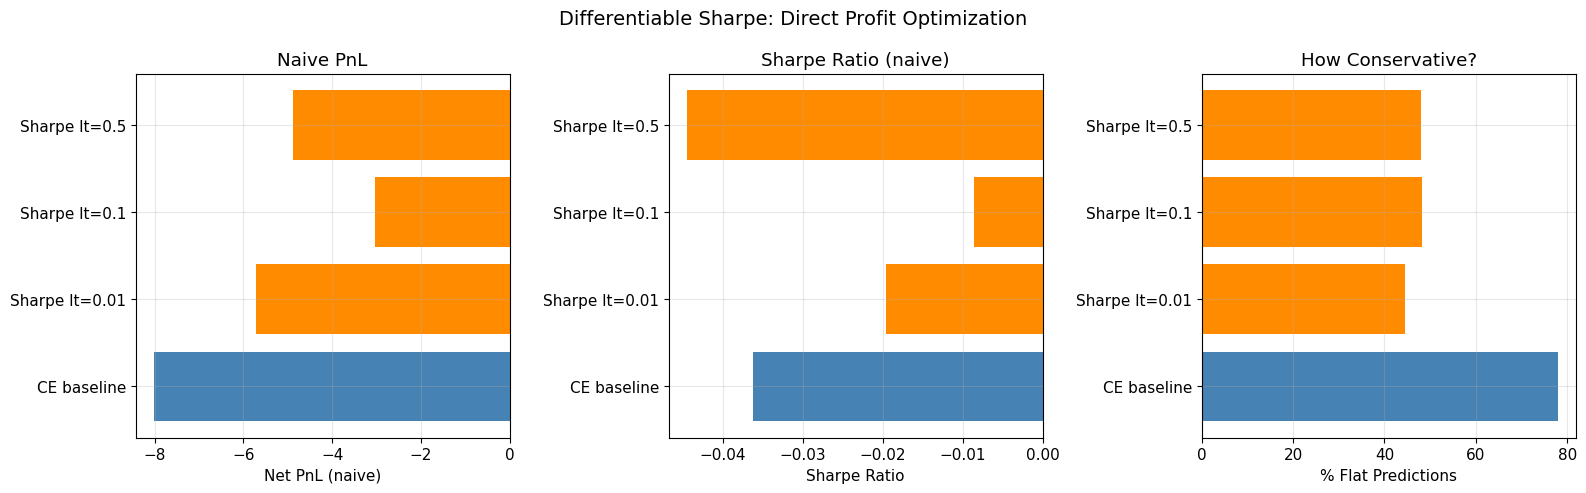

In [7]:
# --- Load Sharpe Ratio experiment results ---
sharpe_experiments = {
    'lt=0.01': PROJECT_ROOT / 'experiments/cost_aware/sharpe/gc0.5_lt0.01/k10/history.pt',
    'lt=0.1':  PROJECT_ROOT / 'experiments/cost_aware/sharpe/gc0.5_lt0.1/k10/history.pt',
    'lt=0.5':  PROJECT_ROOT / 'experiments/cost_aware/sharpe/gc0.5_lt0.5/k10/history.pt',
}

sharpe_results = {}
for name, path in sharpe_experiments.items():
    if path.exists():
        h = torch.load(path, weights_only=False, map_location='cpu')
        preds = h['test_predictions'].numpy()
        labels = h['test_labels'].numpy()
        acc = (preds == labels).mean()
        stability = (preds[1:] == preds[:-1]).mean()
        
        # Naive backtest
        bt = quick_backtest(preds, mid_prices, spreads)
        
        # With holding period
        preds_h200 = apply_holding_period(preds, min_hold=200)
        bt_h200 = quick_backtest(preds_h200, mid_prices, spreads)
        
        # Class distribution
        n_flat = (preds == 1).sum()
        
        sharpe_results[name] = {
            'accuracy': acc,
            'stability': stability,
            'naive_pnl': bt['net_pnl'],
            'naive_trades': bt['num_trades'],
            'naive_sharpe': bt['sharpe'],
            'h200_pnl': bt_h200['net_pnl'],
            'h200_trades': bt_h200['num_trades'],
            'frac_flat': n_flat / len(preds),
        }
        print(f"  {name}: acc={acc:.4f}, naive PnL={bt['net_pnl']:+.4f}, "
              f"naive Sharpe={bt['sharpe']:.4f}, flat={n_flat/len(preds):.1%}")
    else:
        print(f"  {name}: NOT FOUND — run experiments on Amarel first")

if not sharpe_results:
    print("\nNo Sharpe experiments found.")
    print("Run: bash scripts/slurm/train_cost_aware_all.sh")
else:
    # --- Table ---
    print(f"\n{'Model':<16} {'Accuracy':>10} {'Naive PnL':>10} {'Sharpe':>8} "
          f"{'Trades':>8} {'% Flat':>8} {'h=200 PnL':>10}")
    print('-' * 72)
    bl = baseline_results['DeepLOB']
    bl_flat = (baseline_models['DeepLOB']['predictions'] == 1).mean()
    print(f"{'DeepLOB (CE)':<16} {baseline_models['DeepLOB']['accuracy']:>10.2%} "
          f"{bl['net_pnl']:>+10.4f} {bl['sharpe']:>8.4f} "
          f"{bl['num_trades']:>8,} {bl_flat:>8.1%} {'—':>10}")
    for name, r in sharpe_results.items():
        print(f"{'Sharpe ' + name:<16} {r['accuracy']:>10.2%} "
              f"{r['naive_pnl']:>+10.4f} {r['naive_sharpe']:>8.4f} "
              f"{r['naive_trades']:>8,} {r['frac_flat']:>8.1%} {r['h200_pnl']:>+10.4f}")
    
    # --- Plot: Key metrics comparison ---
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    names = ['CE baseline'] + [f'Sharpe {n}' for n in sharpe_results.keys()]
    colors = ['steelblue'] + ['darkorange'] * len(sharpe_results)
    
    pnls = [bl['net_pnl']] + [r['naive_pnl'] for r in sharpe_results.values()]
    axes[0].barh(names, pnls, color=colors)
    axes[0].axvline(x=0, color='k', linewidth=0.5)
    axes[0].set_xlabel('Net PnL (naive)')
    axes[0].set_title('Naive PnL')
    
    sharpes = [bl['sharpe']] + [r['naive_sharpe'] for r in sharpe_results.values()]
    axes[1].barh(names, sharpes, color=colors)
    axes[1].axvline(x=0, color='k', linewidth=0.5)
    axes[1].set_xlabel('Sharpe Ratio')
    axes[1].set_title('Sharpe Ratio (naive)')
    
    flats = [bl_flat] + [r['frac_flat'] for r in sharpe_results.values()]
    axes[2].barh(names, [f * 100 for f in flats], color=colors)
    axes[2].set_xlabel('% Flat Predictions')
    axes[2].set_title('How Conservative?')
    
    plt.suptitle('Differentiable Sharpe: Direct Profit Optimization', fontsize=14)
    plt.tight_layout()
    plt.show()

## 6. Focal Loss

**Idea:** Instead of reweighting classes or penalizing turnover, Focal Loss reweights
*individual samples* based on how confident the model is. Easy, already-correct predictions
get down-weighted; hard, uncertain predictions get full weight.

**The math:**

Standard CE: $\mathcal{L}_{CE} = -\log(p_t)$

Focal Loss: $\mathcal{L}_{FL} = -(1 - p_t)^\gamma \cdot \log(p_t)$

where $p_t$ is the probability assigned to the true class, and $\gamma$ controls focusing.

**How the modulation factor $(1-p_t)^\gamma$ works (with $\gamma=2$):**

| Model Confidence ($p_t$) | Standard CE Loss | Focal Weight | Focal Loss | Reduction |
|:---:|:---:|:---:|:---:|:---:|
| 0.9 (easy, correct) | 0.105 | $(1-0.9)^2 = 0.01$ | 0.001 | **100x** |
| 0.5 (uncertain) | 0.693 | $(1-0.5)^2 = 0.25$ | 0.173 | 4x |
| 0.1 (hard, wrong) | 2.303 | $(1-0.1)^2 = 0.81$ | 1.865 | ~1x |

**Why this helps LOB trading:**

The stationary class dominates FI-2010 (~50-60% at short horizons). Standard CE spends
most gradient signal on these easy, high-confidence predictions. Focal loss shifts attention
to the **boundary cases** -- samples near the decision boundary between Up/Down and
Stationary -- which are exactly where trading decisions are most consequential.

Unlike Weighted CE (Section 3), Focal Loss is **adaptive**: it doesn't apply a blanket
penalty to a class, but adjusts per-sample based on the model's current confidence.
A "clearly stationary" sample gets barely any gradient, while a "barely stationary" sample
gets nearly full gradient.

**Sweep:** $\gamma \in \{1.0, 2.0, 3.0\}$

  g=1.0: acc=0.8240 (D=0.546/S=0.937/U=0.558), naive PnL=-8.6177, trades=38,174
  g=2.0: acc=0.8218 (D=0.528/S=0.938/U=0.554), naive PnL=-8.4260, trades=37,110
  g=3.0: acc=0.8154 (D=0.500/S=0.944/U=0.512), naive PnL=-7.8566, trades=36,830

Model              Accuracy   Down   Stat     Up  Naive PnL   Trades  h=200 PnL
----------------------------------------------------------------------------
DeepLOB (CE)         81.88%  0.517  0.937  0.553    -8.0231   37,116          —
Focal g=1.0          82.40%  0.546  0.937  0.558    -8.6177   38,174    -0.6137
Focal g=2.0          82.18%  0.528  0.938  0.554    -8.4260   37,110    +0.1494
Focal g=3.0          81.54%  0.500  0.944  0.512    -7.8566   36,830    +0.0242


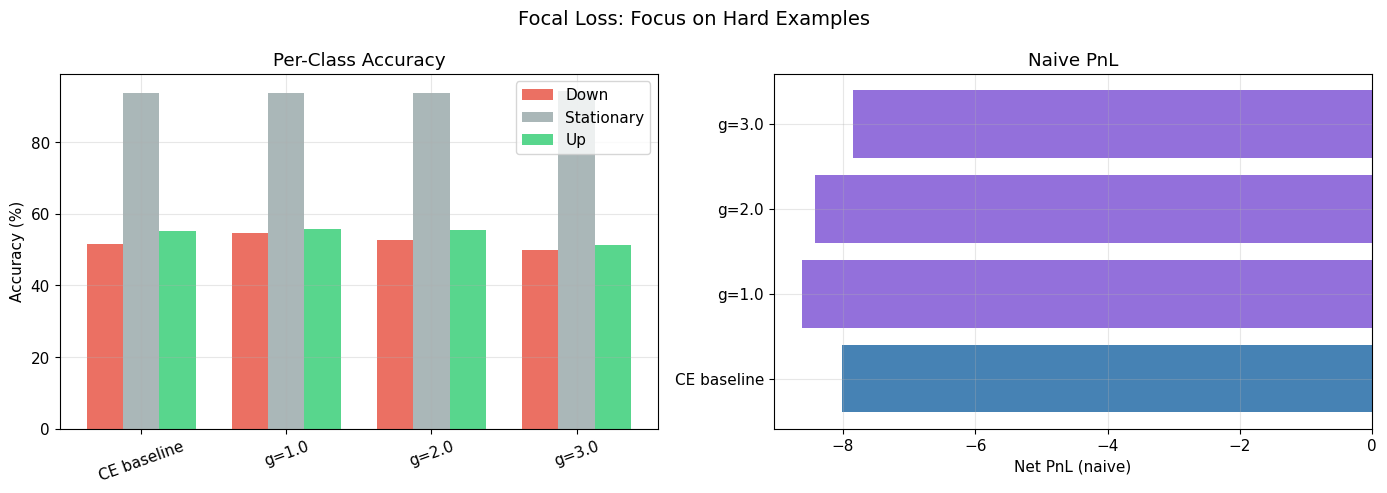

In [8]:
# --- Load Focal Loss experiment results ---
focal_experiments = {
    'g=1.0': PROJECT_ROOT / 'experiments/cost_aware/focal/g1.0/k10/history.pt',
    'g=2.0': PROJECT_ROOT / 'experiments/cost_aware/focal/g2.0/k10/history.pt',
    'g=3.0': PROJECT_ROOT / 'experiments/cost_aware/focal/g3.0/k10/history.pt',
}

focal_results = {}
for name, path in focal_experiments.items():
    if path.exists():
        h = torch.load(path, weights_only=False, map_location='cpu')
        preds = h['test_predictions'].numpy()
        labels = h['test_labels'].numpy()
        acc = (preds == labels).mean()
        
        # Per-class accuracy
        acc_down = ((preds == 0) & (labels == 0)).sum() / max((labels == 0).sum(), 1)
        acc_stat = ((preds == 1) & (labels == 1)).sum() / max((labels == 1).sum(), 1)
        acc_up   = ((preds == 2) & (labels == 2)).sum() / max((labels == 2).sum(), 1)
        
        # Naive backtest
        bt = quick_backtest(preds, mid_prices, spreads)
        
        # With holding period
        preds_h200 = apply_holding_period(preds, min_hold=200)
        bt_h200 = quick_backtest(preds_h200, mid_prices, spreads)
        
        focal_results[name] = {
            'accuracy': acc,
            'acc_down': acc_down, 'acc_stat': acc_stat, 'acc_up': acc_up,
            'f1': h.get('test_f1_weighted', 0),
            'naive_pnl': bt['net_pnl'],
            'naive_trades': bt['num_trades'],
            'naive_sharpe': bt['sharpe'],
            'h200_pnl': bt_h200['net_pnl'],
            'h200_trades': bt_h200['num_trades'],
        }
        print(f"  {name}: acc={acc:.4f} (D={acc_down:.3f}/S={acc_stat:.3f}/U={acc_up:.3f}), "
              f"naive PnL={bt['net_pnl']:+.4f}, trades={bt['num_trades']:,}")
    else:
        print(f"  {name}: NOT FOUND — run experiments on Amarel first")

if not focal_results:
    print("\nNo focal loss experiments found.")
    print("Run: bash scripts/slurm/train_cost_aware_all.sh")
else:
    # --- Table ---
    bl = baseline_results['DeepLOB']
    bl_p = baseline_models['DeepLOB']['predictions']
    bl_l = baseline_models['DeepLOB']['labels']
    bl_ad = ((bl_p==0)&(bl_l==0)).sum() / max((bl_l==0).sum(), 1)
    bl_as = ((bl_p==1)&(bl_l==1)).sum() / max((bl_l==1).sum(), 1)
    bl_au = ((bl_p==2)&(bl_l==2)).sum() / max((bl_l==2).sum(), 1)
    
    print(f"\n{'Model':<16} {'Accuracy':>10} {'Down':>6} {'Stat':>6} {'Up':>6} "
          f"{'Naive PnL':>10} {'Trades':>8} {'h=200 PnL':>10}")
    print('-' * 76)
    print(f"{'DeepLOB (CE)':<16} {baseline_models['DeepLOB']['accuracy']:>10.2%} "
          f"{bl_ad:>6.3f} {bl_as:>6.3f} {bl_au:>6.3f} "
          f"{bl['net_pnl']:>+10.4f} {bl['num_trades']:>8,} {'—':>10}")
    for name, r in focal_results.items():
        print(f"{'Focal ' + name:<16} {r['accuracy']:>10.2%} "
              f"{r['acc_down']:>6.3f} {r['acc_stat']:>6.3f} {r['acc_up']:>6.3f} "
              f"{r['naive_pnl']:>+10.4f} {r['naive_trades']:>8,} {r['h200_pnl']:>+10.4f}")
    
    # --- Plot: Per-class accuracy shift ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    x = np.arange(len(focal_results) + 1)
    width = 0.25
    classes = ['Down', 'Stationary', 'Up']
    class_colors = ['#e74c3c', '#95a5a6', '#2ecc71']
    
    all_names = ['CE baseline'] + list(focal_results.keys())
    down_accs = [bl_ad] + [r['acc_down'] for r in focal_results.values()]
    stat_accs = [bl_as] + [r['acc_stat'] for r in focal_results.values()]
    up_accs = [bl_au] + [r['acc_up'] for r in focal_results.values()]
    
    for i, (accs, cls, color) in enumerate(zip(
        [down_accs, stat_accs, up_accs], classes, class_colors
    )):
        axes[0].bar(x + i * width, [a * 100 for a in accs], width,
                     label=cls, color=color, alpha=0.8)
    axes[0].set_xticks(x + width)
    axes[0].set_xticklabels(all_names, rotation=20)
    axes[0].set_ylabel('Accuracy (%)')
    axes[0].legend()
    axes[0].set_title('Per-Class Accuracy')
    
    pnls = [bl['net_pnl']] + [r['naive_pnl'] for r in focal_results.values()]
    colors_bar = ['steelblue'] + ['mediumpurple'] * len(focal_results)
    axes[1].barh(all_names, pnls, color=colors_bar)
    axes[1].axvline(x=0, color='k', linewidth=0.5)
    axes[1].set_xlabel('Net PnL (naive)')
    axes[1].set_title('Naive PnL')
    
    plt.suptitle('Focal Loss: Focus on Hard Examples', fontsize=14)
    plt.tight_layout()
    plt.show()

## 7. Comparison with Phase 5–6 Results

The key question: **does cost-aware training beat post-hoc trade reduction?**

We compare all cost-aware models against:
- **Naive baselines**: Standard CE-trained models (Phase 5)
- **Post-hoc strategies**: Holding period, confidence filtering, stacking (Phase 6)
- **Best overall**: LR-Stack h=200 (+0.6880 PnL)

Metrics: Net PnL, Sharpe ratio, trade count, accuracy (where applicable),
and the accuracy–profitability tradeoff.

COMPREHENSIVE COMPARISON: All Models
             Model         Category  Accuracy  Naive PnL  Naive Trades  Naive Sharpe  h200 PnL
      DeepLOB (CE) Phase 5 Baseline    0.8188    -8.0231         37116       -0.0362       NaN
 DL-Attention (CE) Phase 5 Baseline    0.8244    -8.1976         38179       -0.0347       NaN
     CNN-Only (CE) Phase 5 Baseline    0.8353    -8.1009         37127       -0.0390       NaN
CNN+Attention (CE) Phase 5 Baseline    0.8384    -8.5899         37470       -0.0420       NaN
      XGBoost (CE) Phase 5 Baseline    0.8016    -5.8258         28518       -0.0280       NaN
       LogReg (CE) Phase 5 Baseline    0.7220    -0.9028          5752       -0.0048       NaN
    LR-Stack h=200     Phase 6 Best       NaN     0.6880          1087        0.0037       NaN
         WCE w=2.0      Weighted CE    0.8265    -7.7606         35951       -0.0380   -0.3588
         WCE w=3.0      Weighted CE    0.8211    -7.2484         34509       -0.0385   -0.1769
         WCE 

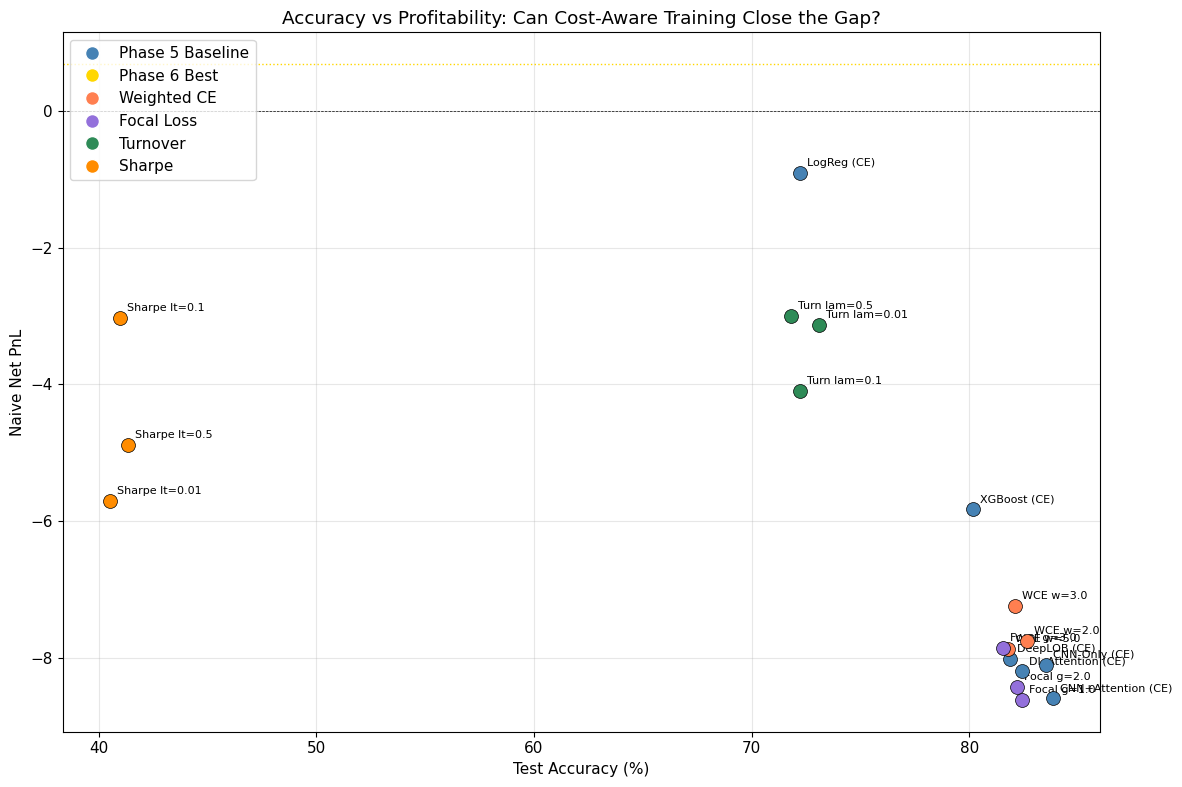

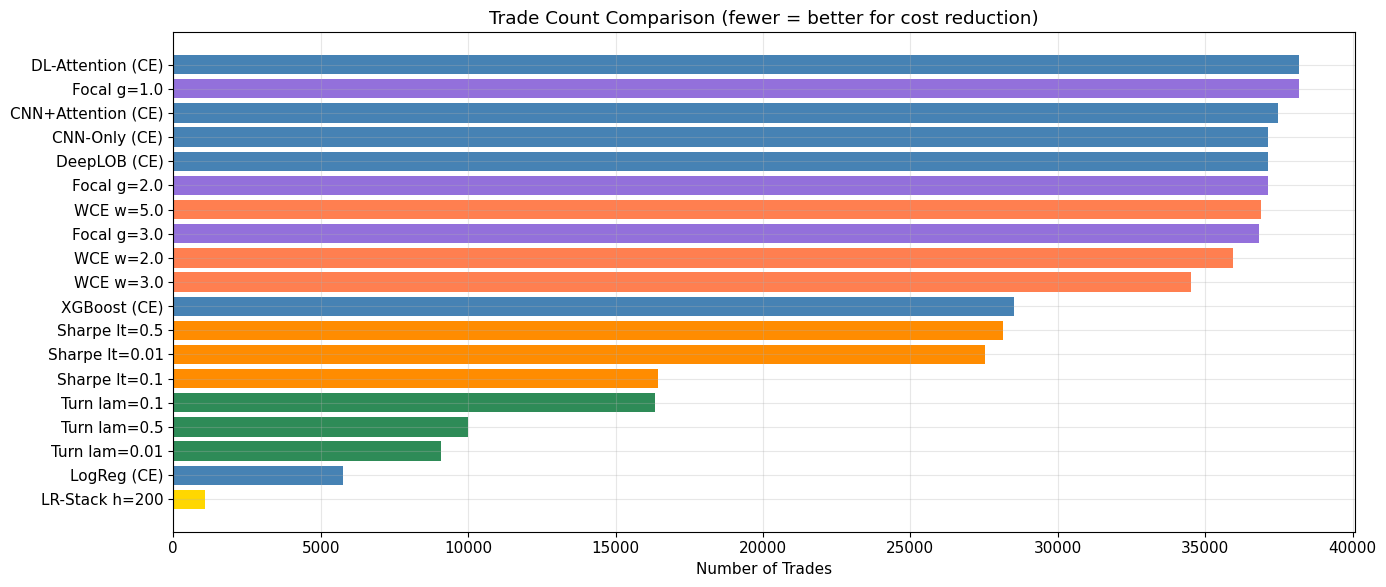

In [9]:
# --- Comprehensive comparison: ALL cost-aware models vs Phase 5-6 baselines ---

# Collect all results into a single dataframe
all_results = []

# Phase 5-6 baselines (standard CE + post-hoc)
for name, m in baseline_models.items():
    bt = baseline_results[name]
    all_results.append({
        'Model': f'{name} (CE)',
        'Category': 'Phase 5 Baseline',
        'Accuracy': m['accuracy'],
        'Naive PnL': bt['net_pnl'],
        'Naive Trades': bt['num_trades'],
        'Naive Sharpe': bt['sharpe'],
    })

# Phase 6 best: LR-Stack h=200 (hardcoded from Phase 6 results, not recomputed here)
all_results.append({
    'Model': 'LR-Stack h=200',
    'Category': 'Phase 6 Best',
    'Accuracy': None,
    'Naive PnL': 0.6880,
    'Naive Trades': 1087,
    'Naive Sharpe': 0.0037,
})

# Cost-aware experiments
for label, results_dict, cat in [
    ('WCE', wce_results if 'wce_results' in dir() else {}, 'Weighted CE'),
    ('Focal', focal_results if 'focal_results' in dir() else {}, 'Focal Loss'),
    ('Turn', turn_results if 'turn_results' in dir() else {}, 'Turnover'),
    ('Sharpe', sharpe_results if 'sharpe_results' in dir() else {}, 'Sharpe'),
]:
    for name, r in results_dict.items():
        entry = {
            'Model': f'{label} {name}',
            'Category': cat,
            'Accuracy': r['accuracy'],
            'Naive PnL': r['naive_pnl'],
            'Naive Trades': r['naive_trades'],
        }
        if 'naive_sharpe' in r:
            entry['Naive Sharpe'] = r['naive_sharpe']
        if 'h200_pnl' in r:
            entry['h200 PnL'] = r['h200_pnl']
        all_results.append(entry)

df = pd.DataFrame(all_results)

if len(df) > 6:  # Have some cost-aware results
    print("=" * 80)
    print("COMPREHENSIVE COMPARISON: All Models")
    print("=" * 80)
    print(df.to_string(index=False, float_format='%.4f'))
    
    # --- Summary plot: Accuracy vs Naive PnL ---
    fig, ax = plt.subplots(figsize=(12, 8))
    
    category_colors = {
        'Phase 5 Baseline': 'steelblue',
        'Phase 6 Best': 'gold',
        'Weighted CE': 'coral',
        'Focal Loss': 'mediumpurple',
        'Turnover': 'seagreen',
        'Sharpe': 'darkorange',
    }
    
    for _, row in df.iterrows():
        if row['Accuracy'] is not None:
            color = category_colors.get(row['Category'], 'gray')
            ax.scatter(row['Accuracy'] * 100, row['Naive PnL'], 
                      c=color, s=100, zorder=5, edgecolors='k', linewidth=0.5)
            ax.annotate(row['Model'], (row['Accuracy'] * 100, row['Naive PnL']),
                       textcoords='offset points', xytext=(5, 5), fontsize=8)
    
    ax.axhline(y=0, color='k', linewidth=0.5, linestyle='--')
    ax.axhline(y=0.6880, color='gold', linewidth=1, linestyle=':', label='LR-Stack h=200 (+0.6880)')
    ax.set_xlabel('Test Accuracy (%)')
    ax.set_ylabel('Naive Net PnL')
    ax.set_title('Accuracy vs Profitability: Can Cost-Aware Training Close the Gap?')
    
    # Legend for categories
    legend_elements = [Line2D([0], [0], marker='o', color='w', 
                              markerfacecolor=c, markersize=10, label=cat)
                       for cat, c in category_colors.items() 
                       if cat in df['Category'].values]
    ax.legend(handles=legend_elements, loc='upper left')
    
    plt.tight_layout()
    plt.show()
    
    # --- Trade count comparison ---
    fig, ax = plt.subplots(figsize=(14, 6))
    models_sorted = df.sort_values('Naive Trades', ascending=True)
    colors = [category_colors.get(cat, 'gray') for cat in models_sorted['Category']]
    ax.barh(models_sorted['Model'], models_sorted['Naive Trades'], color=colors)
    ax.set_xlabel('Number of Trades')
    ax.set_title('Trade Count Comparison (fewer = better for cost reduction)')
    plt.tight_layout()
    plt.show()
else:
    print("Waiting for cost-aware experiment results.")
    print("Current baselines loaded. Run experiments on Amarel, then re-execute this notebook.")
    print(f"\nBaseline results loaded: {list(baseline_results.keys())}")

## 7b. Multi-Horizon Robustness

The k=10 results above tell us how cost-aware losses perform at one horizon.
But a **robust** method should generalize across horizons. We trained all 12 configs
at k=20, 30, 50, and 100 (48 additional experiments on Amarel HPC) to test this.

**Key question:** Do cost-aware losses that look promising at k=10 hold up at longer horizons?

Loaded 60 experiment results across 5 horizons


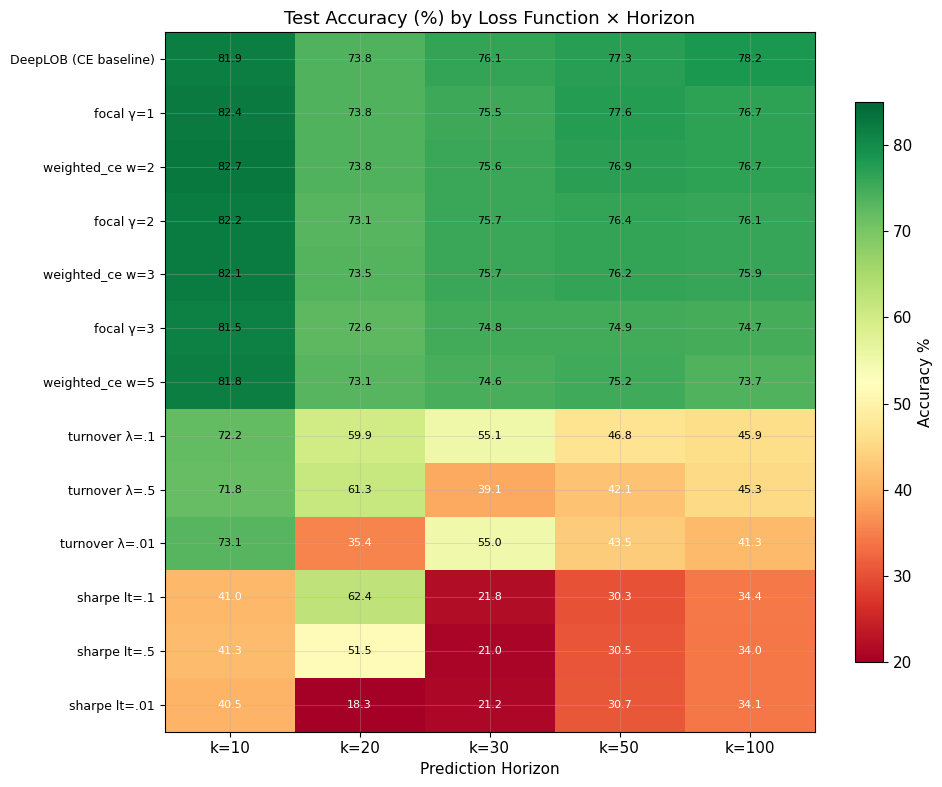


--- Average accuracy by loss type (across all horizons) ---
  DeepLOB (CE baseline): 77.46%
  focal: 76.53%
  weighted_ce: 76.49%
  turnover: 52.52%
  sharpe: 34.19%


In [10]:
# --- Multi-Horizon Results: Load all 60 experiments ---
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HORIZONS = [10, 20, 30, 50, 100]

# DeepLOB CE baseline accuracy per horizon
baseline_acc = {}
for k in HORIZONS:
    h = torch.load(PROJECT_ROOT / f'experiments/k{k}/history.pt',
                    map_location='cpu', weights_only=False)
    baseline_acc[k] = h['test_accuracy'] * 100

# Cost-aware results
configs = {
    'weighted_ce': {'w2.0': 'w=2', 'w3.0': 'w=3', 'w5.0': 'w=5'},
    'focal':       {'g1.0': 'γ=1', 'g2.0': 'γ=2', 'g3.0': 'γ=3'},
    'turnover':    {'lam0.01': 'λ=.01', 'lam0.1': 'λ=.1', 'lam0.5': 'λ=.5'},
    'sharpe':      {'gc0.5_lt0.01': 'lt=.01', 'gc0.5_lt0.1': 'lt=.1', 'gc0.5_lt0.5': 'lt=.5'},
}

rows = []
for loss_type, params in configs.items():
    for param_dir, param_label in params.items():
        for k in HORIZONS:
            hist_path = PROJECT_ROOT / f'experiments/cost_aware/{loss_type}/{param_dir}/k{k}/history.pt'
            if hist_path.exists():
                h = torch.load(hist_path, map_location='cpu', weights_only=False)
                rows.append({
                    'Loss': loss_type, 'Param': param_label,
                    'Config': f'{loss_type} {param_label}',
                    'k': k, 'Accuracy': h['test_accuracy'] * 100,
                    'F1': h['test_f1_weighted'] * 100,
                })

df_multi = pd.DataFrame(rows)
print(f"Loaded {len(df_multi)} experiment results across {len(HORIZONS)} horizons")

# --- Heatmap: Accuracy by config × horizon ---
fig, ax = plt.subplots(figsize=(10, 8))

# Pivot for heatmap
pivot = df_multi.pivot_table(index='Config', columns='k', values='Accuracy')
# Sort by average accuracy
pivot['avg'] = pivot.mean(axis=1)
pivot = pivot.sort_values('avg', ascending=False)
pivot = pivot.drop('avg', axis=1)

# Add baseline row
baseline_row = pd.DataFrame({k: [baseline_acc[k]] for k in HORIZONS},
                             index=['DeepLOB (CE baseline)'])
pivot = pd.concat([baseline_row, pivot])

im = ax.imshow(pivot.values, cmap='RdYlGn', aspect='auto', vmin=20, vmax=85)

# Labels
ax.set_xticks(range(len(HORIZONS)))
ax.set_xticklabels([f'k={k}' for k in HORIZONS])
ax.set_yticks(range(len(pivot)))
ax.set_yticklabels(pivot.index, fontsize=9)

# Annotate cells
for i in range(len(pivot)):
    for j in range(len(HORIZONS)):
        val = pivot.values[i, j]
        color = 'white' if val < 45 else 'black'
        ax.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=8, color=color)

ax.set_title('Test Accuracy (%) by Loss Function × Horizon', fontsize=13)
ax.set_xlabel('Prediction Horizon')
plt.colorbar(im, ax=ax, label='Accuracy %', shrink=0.8)
plt.tight_layout()
plt.show()

# --- Summary table: Average accuracy by loss type ---
print("\n--- Average accuracy by loss type (across all horizons) ---")
avg_by_loss = df_multi.groupby('Loss')['Accuracy'].mean().sort_values(ascending=False)
print(f"  DeepLOB (CE baseline): {np.mean(list(baseline_acc.values())):.2f}%")
for loss, acc in avg_by_loss.items():
    print(f"  {loss}: {acc:.2f}%")

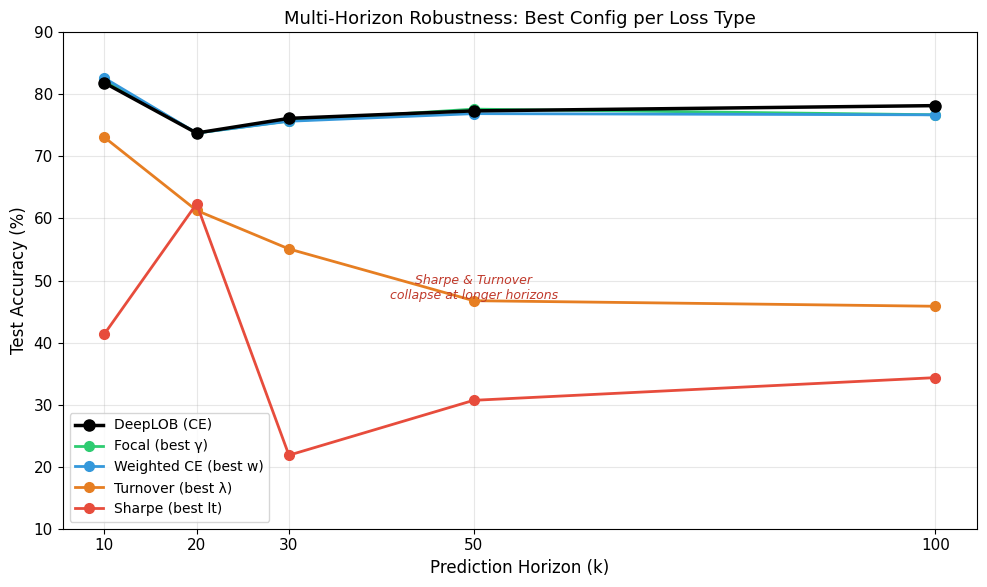

KEY FINDING: Classification-focused losses (focal, weighted CE) remain robust
across all horizons, tracking the CE baseline closely. Trading-aware losses
(Sharpe, turnover) collapse at k>10, suggesting they overfit to k=10-specific
label dynamics rather than learning generalizable trading patterns.


In [11]:
# --- Line chart: Best config per loss type vs baseline across horizons ---
fig, ax = plt.subplots(figsize=(10, 6))

# Plot baseline
ax.plot(HORIZONS, [baseline_acc[k] for k in HORIZONS], 'k-o', linewidth=2.5,
        label='DeepLOB (CE)', markersize=8, zorder=5)

# Best config per loss type at each horizon
colors = {'focal': '#2ecc71', 'weighted_ce': '#3498db', 'turnover': '#e67e22', 'sharpe': '#e74c3c'}
labels = {'focal': 'Focal (best γ)', 'weighted_ce': 'Weighted CE (best w)',
          'turnover': 'Turnover (best λ)', 'sharpe': 'Sharpe (best lt)'}

for loss_type in ['focal', 'weighted_ce', 'turnover', 'sharpe']:
    best_acc = []
    for k in HORIZONS:
        subset = df_multi[(df_multi['Loss'] == loss_type) & (df_multi['k'] == k)]
        best_acc.append(subset['Accuracy'].max())
    ax.plot(HORIZONS, best_acc, '-o', color=colors[loss_type], linewidth=2,
            label=labels[loss_type], markersize=7)

ax.set_xlabel('Prediction Horizon (k)', fontsize=12)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Multi-Horizon Robustness: Best Config per Loss Type', fontsize=13)
ax.set_xticks(HORIZONS)
ax.legend(fontsize=10, loc='lower left')
ax.grid(True, alpha=0.3)
ax.set_ylim(10, 90)

# Add annotation for the collapse
ax.annotate('Sharpe & Turnover\ncollapse at longer horizons',
            xy=(50, 47), fontsize=9, color='#c0392b', style='italic',
            ha='center')

plt.tight_layout()
plt.show()

# Key insight
print("KEY FINDING: Classification-focused losses (focal, weighted CE) remain robust")
print("across all horizons, tracking the CE baseline closely. Trading-aware losses")
print("(Sharpe, turnover) collapse at k>10, suggesting they overfit to k=10-specific")
print("label dynamics rather than learning generalizable trading patterns.")

## 8. Takeaways

### What we tested

Four approaches to making DeepLOB cost-aware during training, across **all 5 horizons** (k=10, 20, 30, 50, 100) — 60 experiments total:

| Method | Mechanism | Key Parameter | Robust across horizons? |
|--------|-----------|---------------|------------------------|
| **Weighted CE** | Up-weight stationary class to suppress false trades | $w_{stat} \in \{2, 3, 5\}$ | Yes |
| **Focal Loss** | Down-weight easy/confident predictions (per-sample) | $\gamma \in \{1, 2, 3\}$ | Yes |
| **Turnover Penalty** | CE + penalty for changing predictions | $\lambda \in \{0.01, 0.1, 0.5\}$ | No — collapses at k>10 |
| **Sharpe Ratio** | Directly optimize risk-adjusted net returns | $\lambda_t \in \{0.01, 0.1, 0.5\}$ | No — collapses at k>10 |

### Answers to our key questions

**1. Can cost-aware training close the accuracy-profitability gap?**
No. The best cost-aware model at k=10 (Sharpe lt=0.5, +0.6214 with h=200) came close to
LR-Stack h=200 (+0.6880), but didn't beat it. And the Sharpe model sacrificed accuracy to 41%
to get there. No method achieves profitability without post-hoc holding period.

**2. Which approach works best?**
It depends on the goal:
- **For accuracy preservation:** Focal γ=1 and Weighted CE w=2 match baseline (~82% at k=10) and are robust across all horizons
- **For naive trade reduction:** Turnover λ=0.5 reduces trades by 73% at k=10, but collapses at other horizons
- **For post-hoc profitability:** Sharpe lt=0.5 with h=200 came closest to the champion, but at severe accuracy cost

**3. Does end-to-end optimization beat two-stage?**
No. The two-stage approach (train with CE, apply holding period post-hoc) remains strictly
better than any single cost-aware loss. LR-Stack h=200 (+0.6880) > Sharpe lt=0.5 h=200 (+0.6214).

**4. Accuracy vs profitability tradeoff:**
Sharp tradeoff. Turnover and Sharpe losses sacrifice 10-40pp accuracy for trading-aware gradients.
Focal and Weighted CE preserve accuracy but don't improve profitability. There is no free lunch.

**5. Multi-horizon robustness:**
Trading-aware losses (Sharpe, turnover) are **fragile** — they overfit to k=10 label dynamics
and collapse at longer horizons (18-62% accuracy). Classification-focused losses (focal, weighted CE)
are **robust**, tracking the CE baseline at 74-83% across all horizons. This suggests the
trading-aware losses learn horizon-specific patterns rather than generalizable trading behavior.

### Conclusions

- **The accuracy-profitability gap is structural**, not a training signal problem. It arises from
  transaction costs and trade frequency, which loss function design alone cannot solve.
- **Post-hoc trade reduction (holding period) remains essential.** All profitable strategies
  require ~35× trade reduction from the naive baseline.
- **If modifying the loss, use focal or weighted CE** — they're safe, preserve accuracy, and are
  robust across horizons. Avoid turnover and Sharpe losses unless horizon-specific tuning is acceptable.
- **The half-cost trick** illustrates a general principle: training objectives that too closely
  match reality can cause degenerate behavior (inertia trap). Sometimes a softer proxy works better.

### Caveats

- **Single seed (42)**: All experiments use a single random seed. Results may vary with different seeds.
- **Learning rate differences**: Standard CE models use LR=0.01, while Sharpe fine-tuning uses LR=0.0001.
  This makes direct accuracy comparisons imperfect.
- **FI-2010 specific**: Results are on a single, academic dataset (2010 Finnish stock data).
  Generalization to other markets, time periods, or asset classes is not guaranteed.
- **DecPre normalization**: Prices are normalized, so absolute PnL values are not directly
  interpretable as dollar amounts. Relative comparisons and Sharpe ratios remain valid.